In [1]:
# using Pkg; Pkg.add("Contour")
# Pkg.add(["Images", "ImageIO", "FileIO", "ImageTransformations"])
# Pkg.add("CoordinateTransformations")
ENV["PYTHON"] = "/home/arun/miniconda3/envs/py311/bin/python" 
import Pkg
Pkg.build("PyCall")

    Building Conda ─→ `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/8f06b0cfa4c514c7b9546756dbae91fcfbc92dc9/build.log`
    Building PyCall → `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/9816a3826b0ebf49ab4926e2b18842ad8b5c8f04/build.log`


In [2]:
using CairoMakie
using DifferentialEquations
using SymPy
using LinearAlgebra
# using Contour


In [3]:
Axis = CairoMakie.Axis

Makie.Axis

In [4]:
function prey_predator!(du, u, param, t)
    x,y  = u
    alpha, beta, gamma, delta = param
    du[1] = alpha*x - beta*x*y
    du[2] = delta*x*y - gamma * y
end

prey_predator! (generic function with 1 method)

## Nullclines

In [5]:
function elem_of_f(f!, elem, u, param, t)
    du = zeros(length(u))
    f!(du, u, param, t)
    return du[elem]
end

elem_of_f (generic function with 1 method)

In [6]:
function draw_nullcline!(ax, f!, xory, param, color, linewidth)
    
    time_now = 0.0
    
    xs = LinRange(-5,10.0,100)
    ys = LinRange(-5,10.0,100)
    
    t = 0
    dxs = [elem_of_f(f!, xory, [x,y], param, t) for x in xs, y in ys]
    contour!(ax, xs, ys, dxs, levels=[0.0], color=color, linewidth=linewidth)
end

draw_nullcline! (generic function with 1 method)

In [7]:
function draw_arrows_on_nullcline!(ax, f!, xory, param, color, linewidth, lengthscale)

    alpha, beta, gamma, delta = param
    
    xs = LinRange(-5,10.0,100)
    ys = LinRange(-5,10.0,100)    

    
    xs_few = LinRange(-5,10.0,10)
    ys_few = LinRange(-5,10.0,10)

    
    t = 0
    dxs = [elem_of_f(f!, xory, [x,y], param, t) for x in xs, y in ys]
    contour!(ax, xs, ys, dxs, levels=[0.0], color=color, linewidth=linewidth)
    
    if xory == 1
        u_along = [(0,y_now) for y_now in ys_few ]
        arrows2d!(ax, zeros(length(ys_few)), ys_few, [0.0], [elem_of_f(prey_predator!, 2, u_now, params, t) for u_now in u_along], lengthscale=lengthscale)
        
        u_along = [(x_now, alpha/beta) for x_now in xs_few]
        arrows2d!(ax, xs_few, (alpha/beta)ones(length(xs_few)), [0.0], [elem_of_f(prey_predator!, 2, u_now, params, t) for u_now in u_along], lengthscale=lengthscale)
    else
        
        u_along = [((gamma/delta),y_now) for y_now in ys_few ]
        arrows2d!(ax, (gamma/delta)*ones(length(ys_few)), ys_few,  [elem_of_f(prey_predator!, 1, u_now, params, t) for u_now in u_along], [0.0], lengthscale=lengthscale)

        u_along = [(x_now, 0.0) for x_now in xs_few]
        arrows2d!(ax, xs_few, zeros(length(xs_few)), [elem_of_f(prey_predator!, 1, u_now, params, t) for u_now in u_along], [0.0], lengthscale=lengthscale)
    end
end

draw_arrows_on_nullcline! (generic function with 1 method)

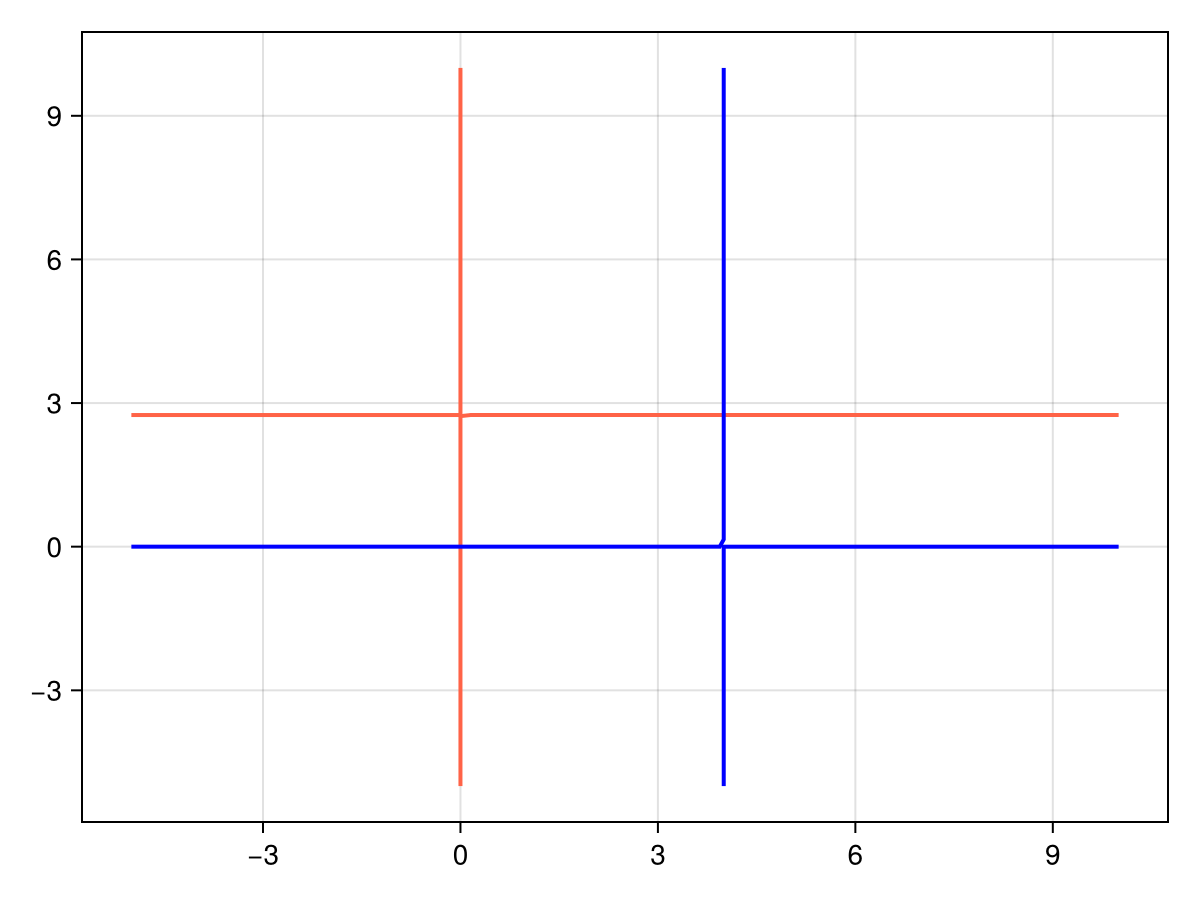

In [8]:
params = [1.1, 0.4, 0.4, 0.1]
fig = Figure(figsize=(500,500))
ax = Axis(fig[1,1])

draw_nullcline!(ax, prey_predator!, 1, params, :tomato, 2)
draw_nullcline!(ax, prey_predator!, 2, params, :blue, 2)

fig

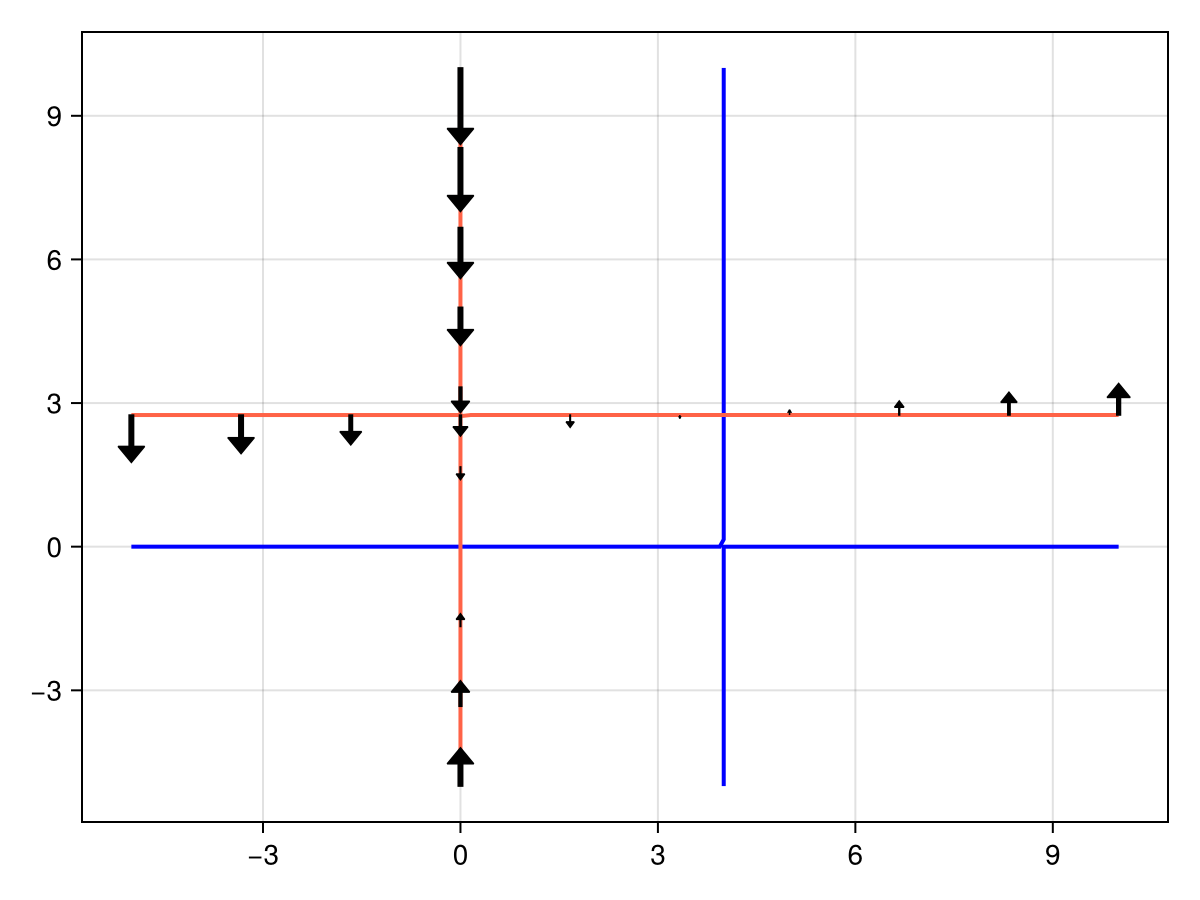

In [9]:
params = [1.1, 0.4, 0.4, 0.1]
fig = Figure(figsize=(500,500))
ax = Axis(fig[1,1])

# draw_nullcline!(ax, prey_predator!, 1, params, :tomato, 2)
draw_nullcline!(ax, prey_predator!, 2, params, :blue, 2)
draw_arrows_on_nullcline!(ax, prey_predator!, 1, params, :tomato, 2, 0.4)
# draw_arrows_on_nullcline!(ax, prey_predator!, 2, params, :blue, 2, 0.4)

fig

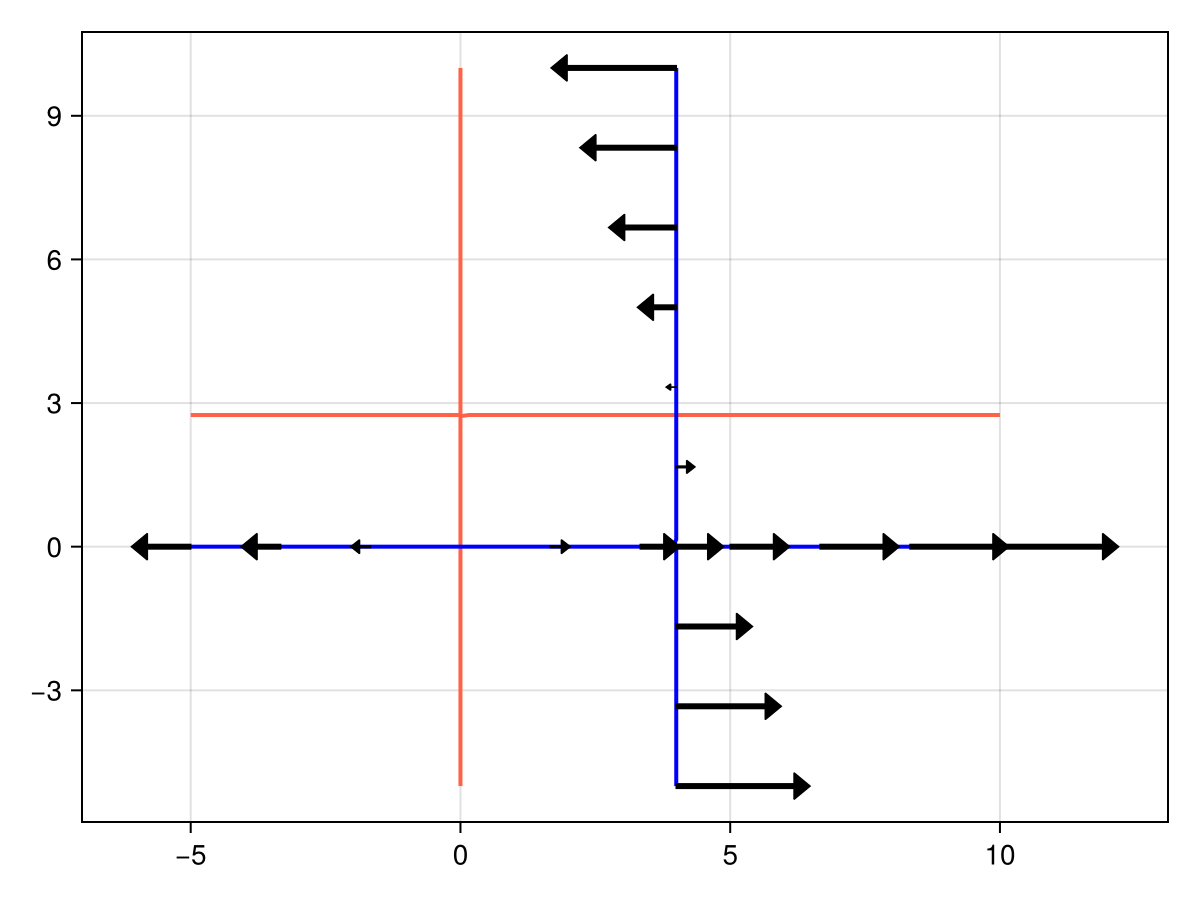

In [10]:
params = [1.1, 0.4, 0.4, 0.1]
fig = Figure(figsize=(500,500))
ax = Axis(fig[1,1])

draw_nullcline!(ax, prey_predator!, 1, params, :tomato, 2)
# draw_nullcline!(ax, prey_predator!, 2, params, :blue, 2)
# draw_arrows_on_nullcline!(ax, prey_predator!, 1, params, :tomato, 2, 0.4)
draw_arrows_on_nullcline!(ax, prey_predator!, 2, params, :blue, 2, 0.2)

fig

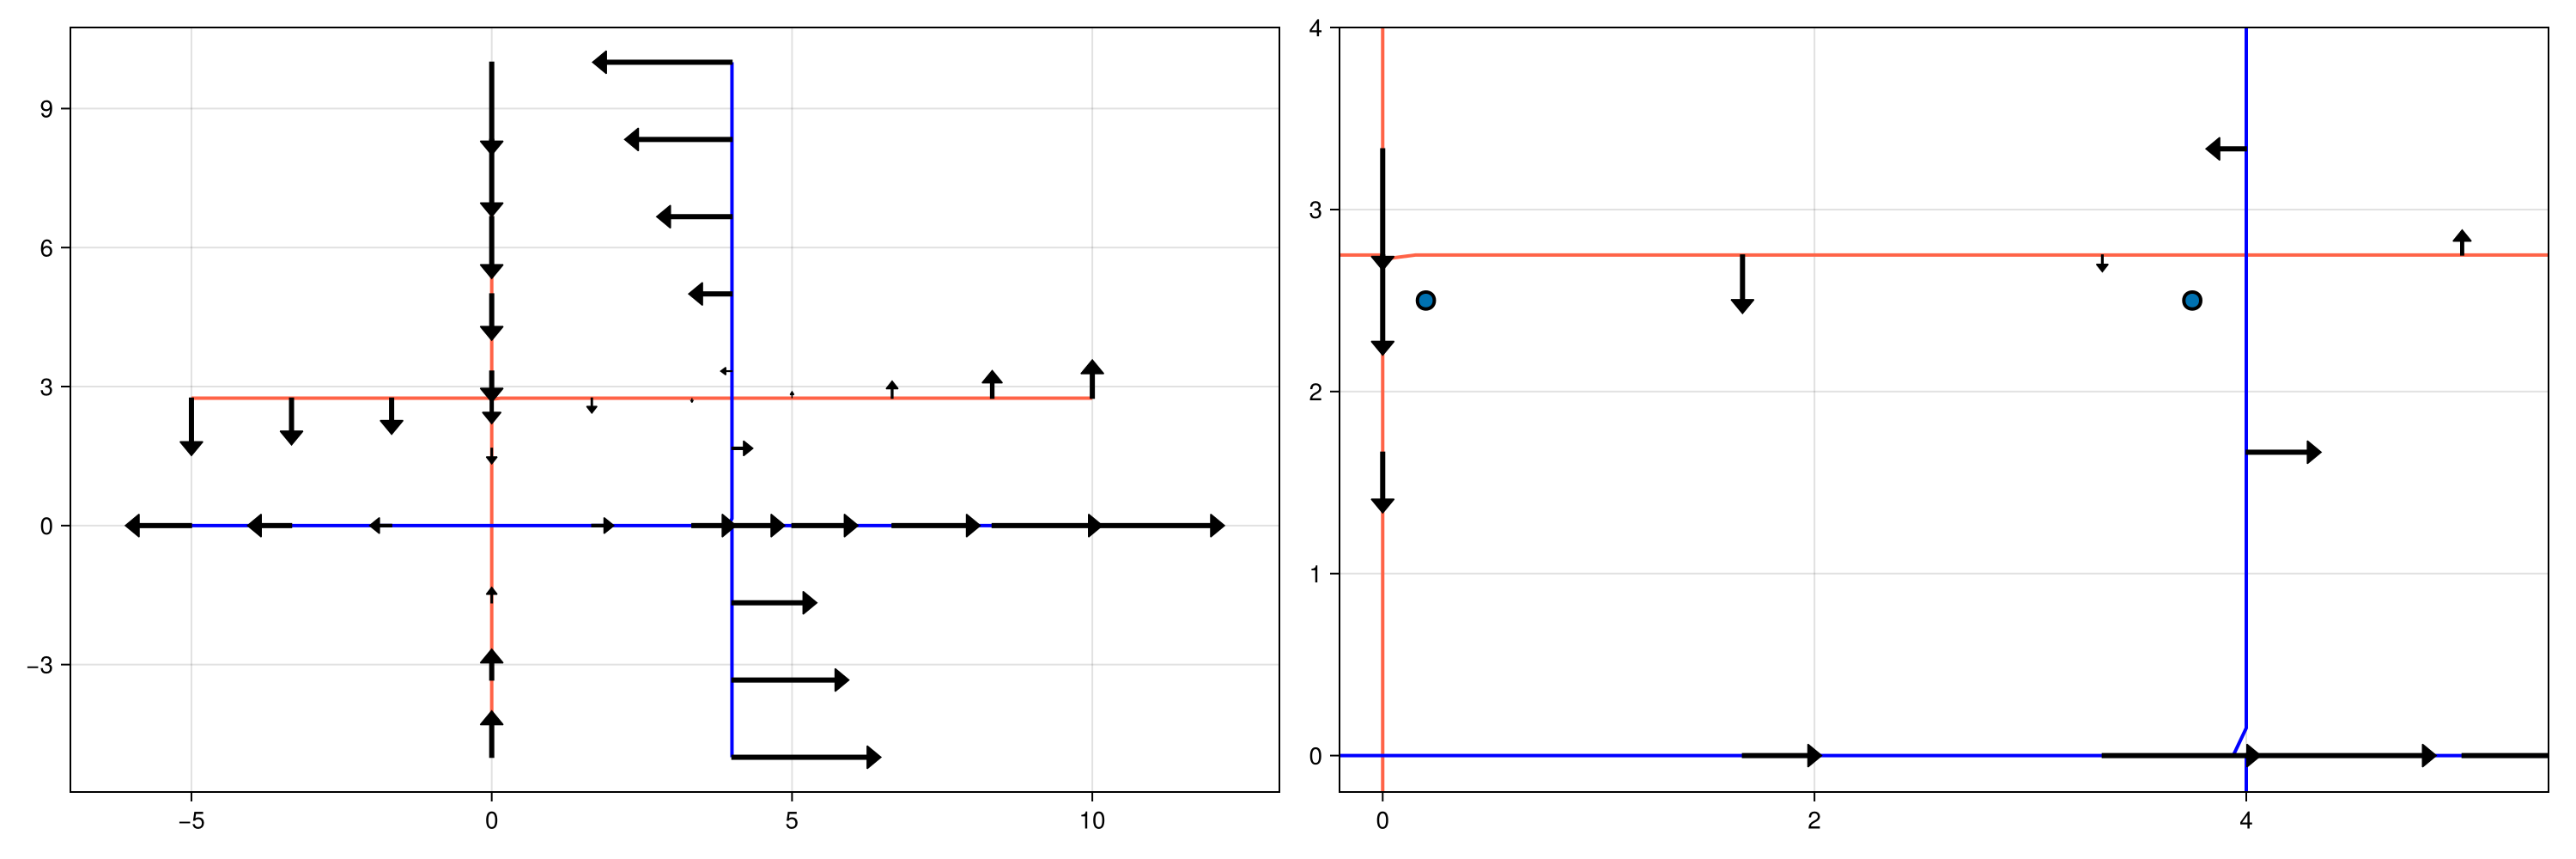

In [12]:
params = [1.1, 0.4, 0.4, 0.1]
fig = Figure(size=(1500,500))
ga = fig[1,1] = GridLayout()
gb = fig[1,2] = GridLayout()
ax1 = Axis(ga[1,1])
ax2 = Axis(gb[1,1])

# draw_nullcline!(ax, prey_predator!, 1, params, :tomato, 2)
# draw_nullcline!(ax, prey_predator!, 2, params, :blue, 2)
draw_arrows_on_nullcline!(ax1, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax1, prey_predator!, 2, params, :blue, 2, 0.2)


draw_arrows_on_nullcline!(ax2, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax2, prey_predator!, 2, params, :blue, 2, 0.2)

init1 = [0.2, 2.5]
init2 = [3.75, 2.5]

scatter!(ax2, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
xlims!(ax2, -0.2,5.4)
ylims!(ax2, -0.2,4)
fig

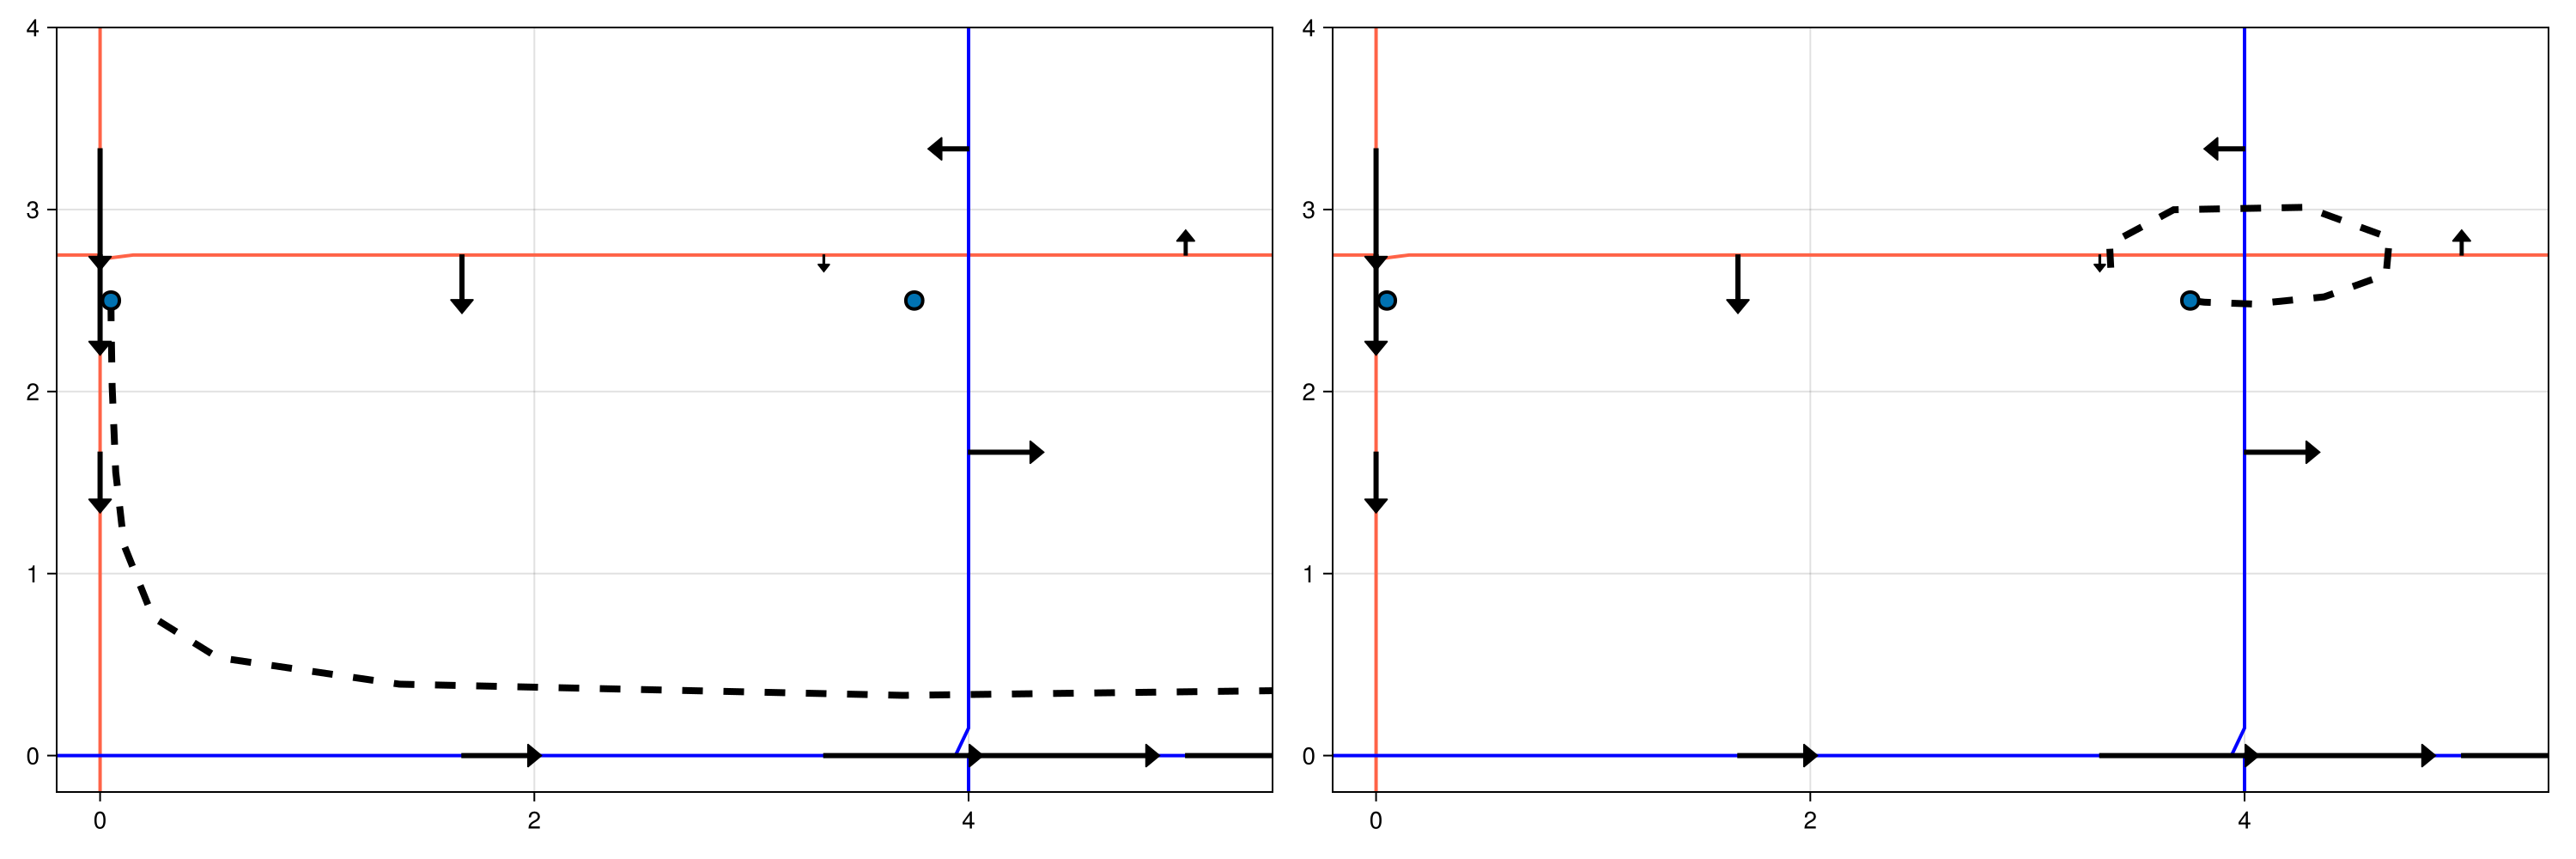

In [13]:
params = [1.1, 0.4, 0.4, 0.1]
fig = Figure(size=(1500,500))
ga = fig[1,1] = GridLayout()
gb = fig[1,2] = GridLayout()
ax1 = Axis(ga[1,1])
ax2 = Axis(gb[1,1])

# draw_nullcline!(ax, prey_predator!, 1, params, :tomato, 2)
# draw_nullcline!(ax, prey_predator!, 2, params, :blue, 2)
draw_arrows_on_nullcline!(ax1, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax1, prey_predator!, 2, params, :blue, 2, 0.2)


draw_arrows_on_nullcline!(ax2, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax2, prey_predator!, 2, params, :blue, 2, 0.2)

init1 = [0.05, 2.5]
init2 = [3.75, 2.5]

l_axs = [ax1, ax2]
l_inits = [init1, init2]
tspan = (0.0,8)

for (ax,init) in zip(l_axs, l_inits)
    prob = ODEProblem(prey_predator!, init, tspan, params)
    sol = solve(prob)
    lines!(ax, sol[1,:], sol[2,:], color=:black, linestyle=:dash, linewidth=4)
end

scatter!(ax1, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
scatter!(ax2, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
xlims!(ax1, -0.2,5.4)
ylims!(ax1, -0.2,4)
xlims!(ax2, -0.2,5.4)
ylims!(ax2, -0.2,4)

fig

In [14]:
@syms R F α β γ δ

dR = α*R - β*R*F
dF = δ*R*F - γ*F
[dR ; dF]

2-element Vector{Sym{PyCall.PyObject}}:
 -F⋅R⋅β + R⋅α
  F⋅R⋅δ - F⋅γ

In [15]:
dNs = [dR, dF]
Ns = [R, F]

2-element Vector{Sym{PyCall.PyObject}}:
 R
 F

In [16]:
equilibria = solve(dNs, Ns)

2-element Vector{Tuple{Sym{PyCall.PyObject}, Sym{PyCall.PyObject}}}:
 (0, 0)
 (γ/δ, α/β)

In [17]:
Jac = Matrix([
    diff(dR, R)  diff(dR, F);
    diff(dF, R)  diff(dF, F)
])

2×2 Matrix{Sym{PyCall.PyObject}}:
 -F⋅β + α     -R⋅β
      F⋅δ  R⋅δ - γ

In [18]:
l_jeval = []
for eq in equilibria
    println("Equilibrium: ", eq)
    sub_dict = Dict(R => eq[1], F => eq[2])
    J_eval = Jac.subs(sub_dict)
    push!(l_jeval, J_eval)
end

Equilibrium: (0, 0)
Equilibrium: (γ/δ, α/β)


In [19]:
l_jeval[1]

2×2 Matrix{Sym{PyCall.PyObject}}:
 α   0
 0  -γ

In [20]:
l_jeval[2]

2×2 Matrix{Sym{PyCall.PyObject}}:
     0  -β*γ/δ
 α*δ/β       0

In [21]:
function plot_eigs!(ax, param_dict, eq_number)

    jac_eval = l_jeval[eq_number].subs(param_dict)
    eigs = eigen(jac_eval).values

    scatter!(ax, Float64(real(eigs[1])), Float64(imag(eigs[1])), markersize=10, strokewidth=2 )
    scatter!(ax, Float64(real(eigs[2])), Float64(imag(eigs[2])), markersize=10, strokewidth=2 )

end

plot_eigs! (generic function with 1 method)

In [22]:
# img = load("/home/arun/Downloads/monaLisa.jpg") 
# img = imresize(img, ratio=1/10)
# save("/home/arun/Downloads/monaLisa.jpg", img)

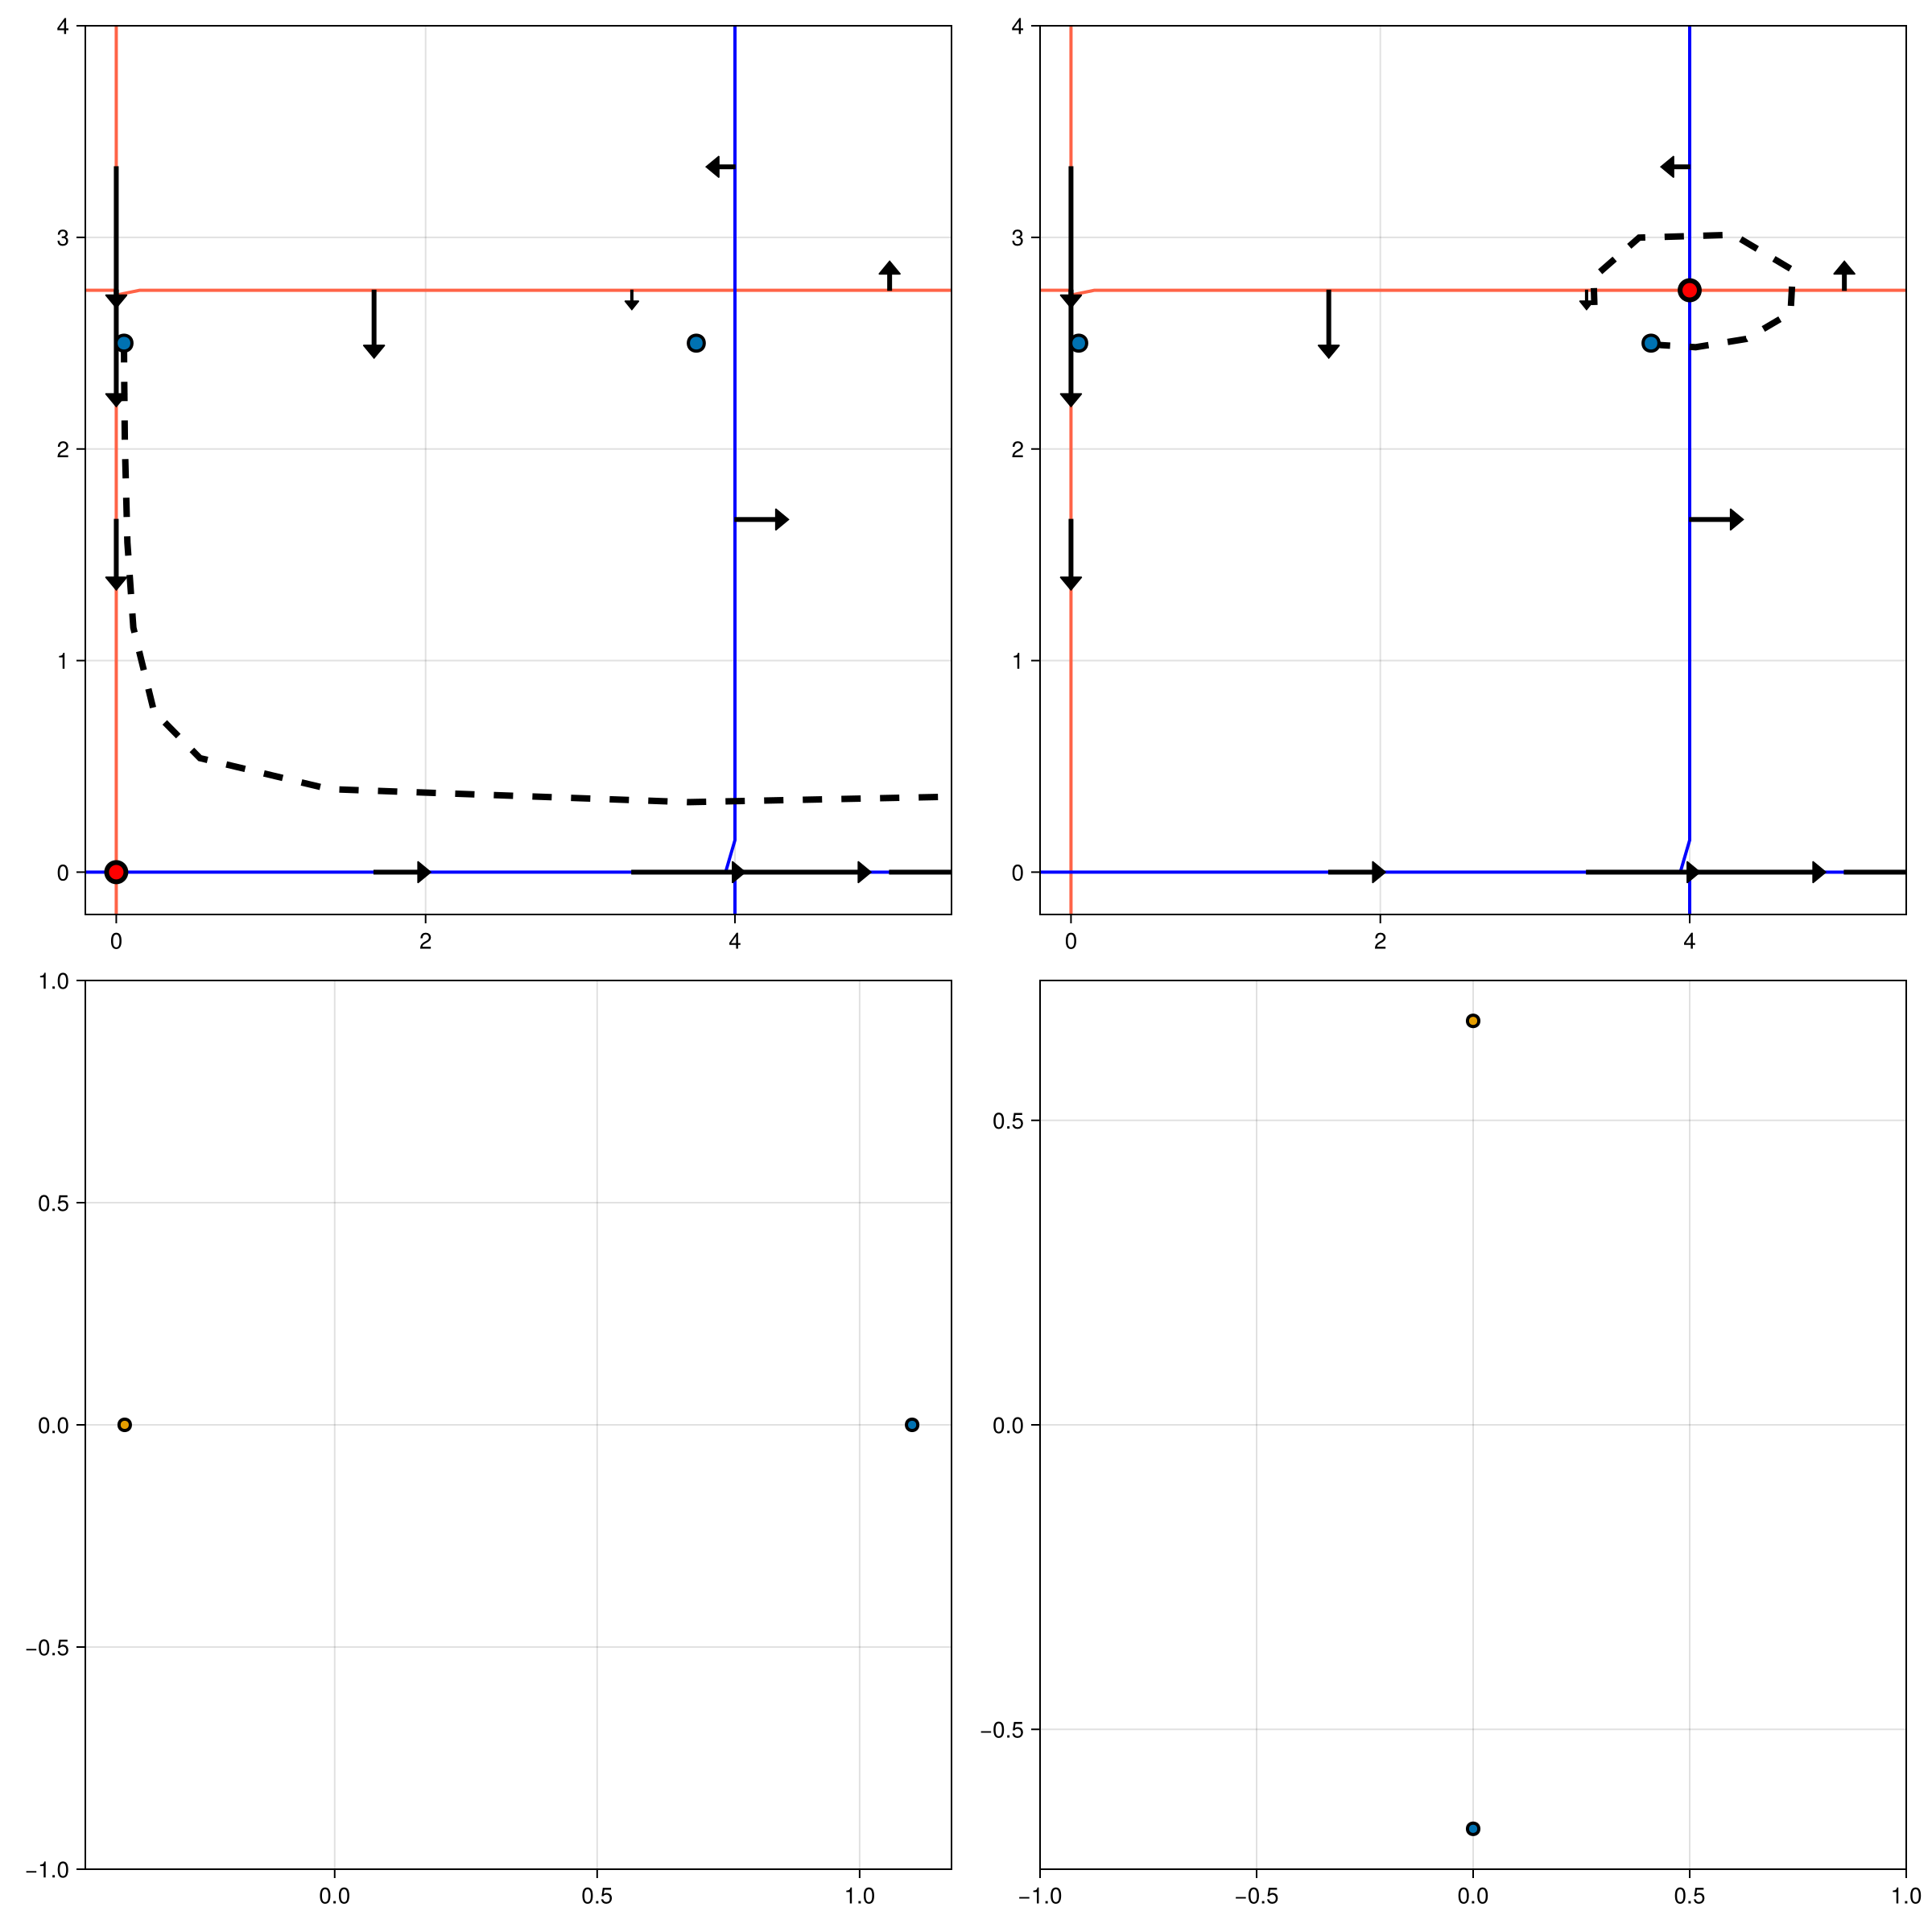

In [57]:

fig = Figure(size=(1200,1200))
ga = fig[1,1] = GridLayout()
gb = fig[2,1] = GridLayout()



gc = fig[1,2] = GridLayout()
gd = fig[2,2] = GridLayout()



ax1 = Axis(ga[1,1]) 
ax2 = Axis(gb[1,1])

ax3 = Axis(gc[1,1])
ax4 = Axis(gd[1,1])



param_dict = Dict(α => params[1] , β => params[2], γ => params[3], δ => params[4])

l_eqs = [[Float64(eq[1].subs(param_dict)), Float64(eq[2].subs(param_dict))] for eq in equilibria] 
plot_eigs!(ax2, param_dict, 1)
plot_eigs!(ax4, param_dict, 2)


draw_arrows_on_nullcline!(ax1, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax1, prey_predator!, 2, params, :blue, 2, 0.2)


draw_arrows_on_nullcline!(ax3, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax3, prey_predator!, 2, params, :blue, 2, 0.2)

scatter!(ax1, [l_eqs[1][1]],[l_eqs[1][2]], markersize=17, strokewidth=3, color=:red)
scatter!(ax3, [l_eqs[2][1]],[l_eqs[2][2]], markersize=17, strokewidth=3, color=:red)


init1 = [0.05, 2.5]
init2 = [3.75, 2.5]

l_axs = [ax1, ax3]
l_inits = [init1, init2]
tspan = (0.0,8)

for (ax,init) in zip(l_axs, l_inits)
    prob = ODEProblem(prey_predator!, init, tspan, params)
    sol = solve(prob)
    lines!(ax, sol[1,:], sol[2,:], color=:black, linestyle=:dash, linewidth=4)
end

scatter!(ax1, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
scatter!(ax3, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
xlims!(ax1, -0.2,5.4)
ylims!(ax1, -0.2,4)
xlims!(ax3, -0.2,5.4)
ylims!(ax3, -0.2,4)


fig

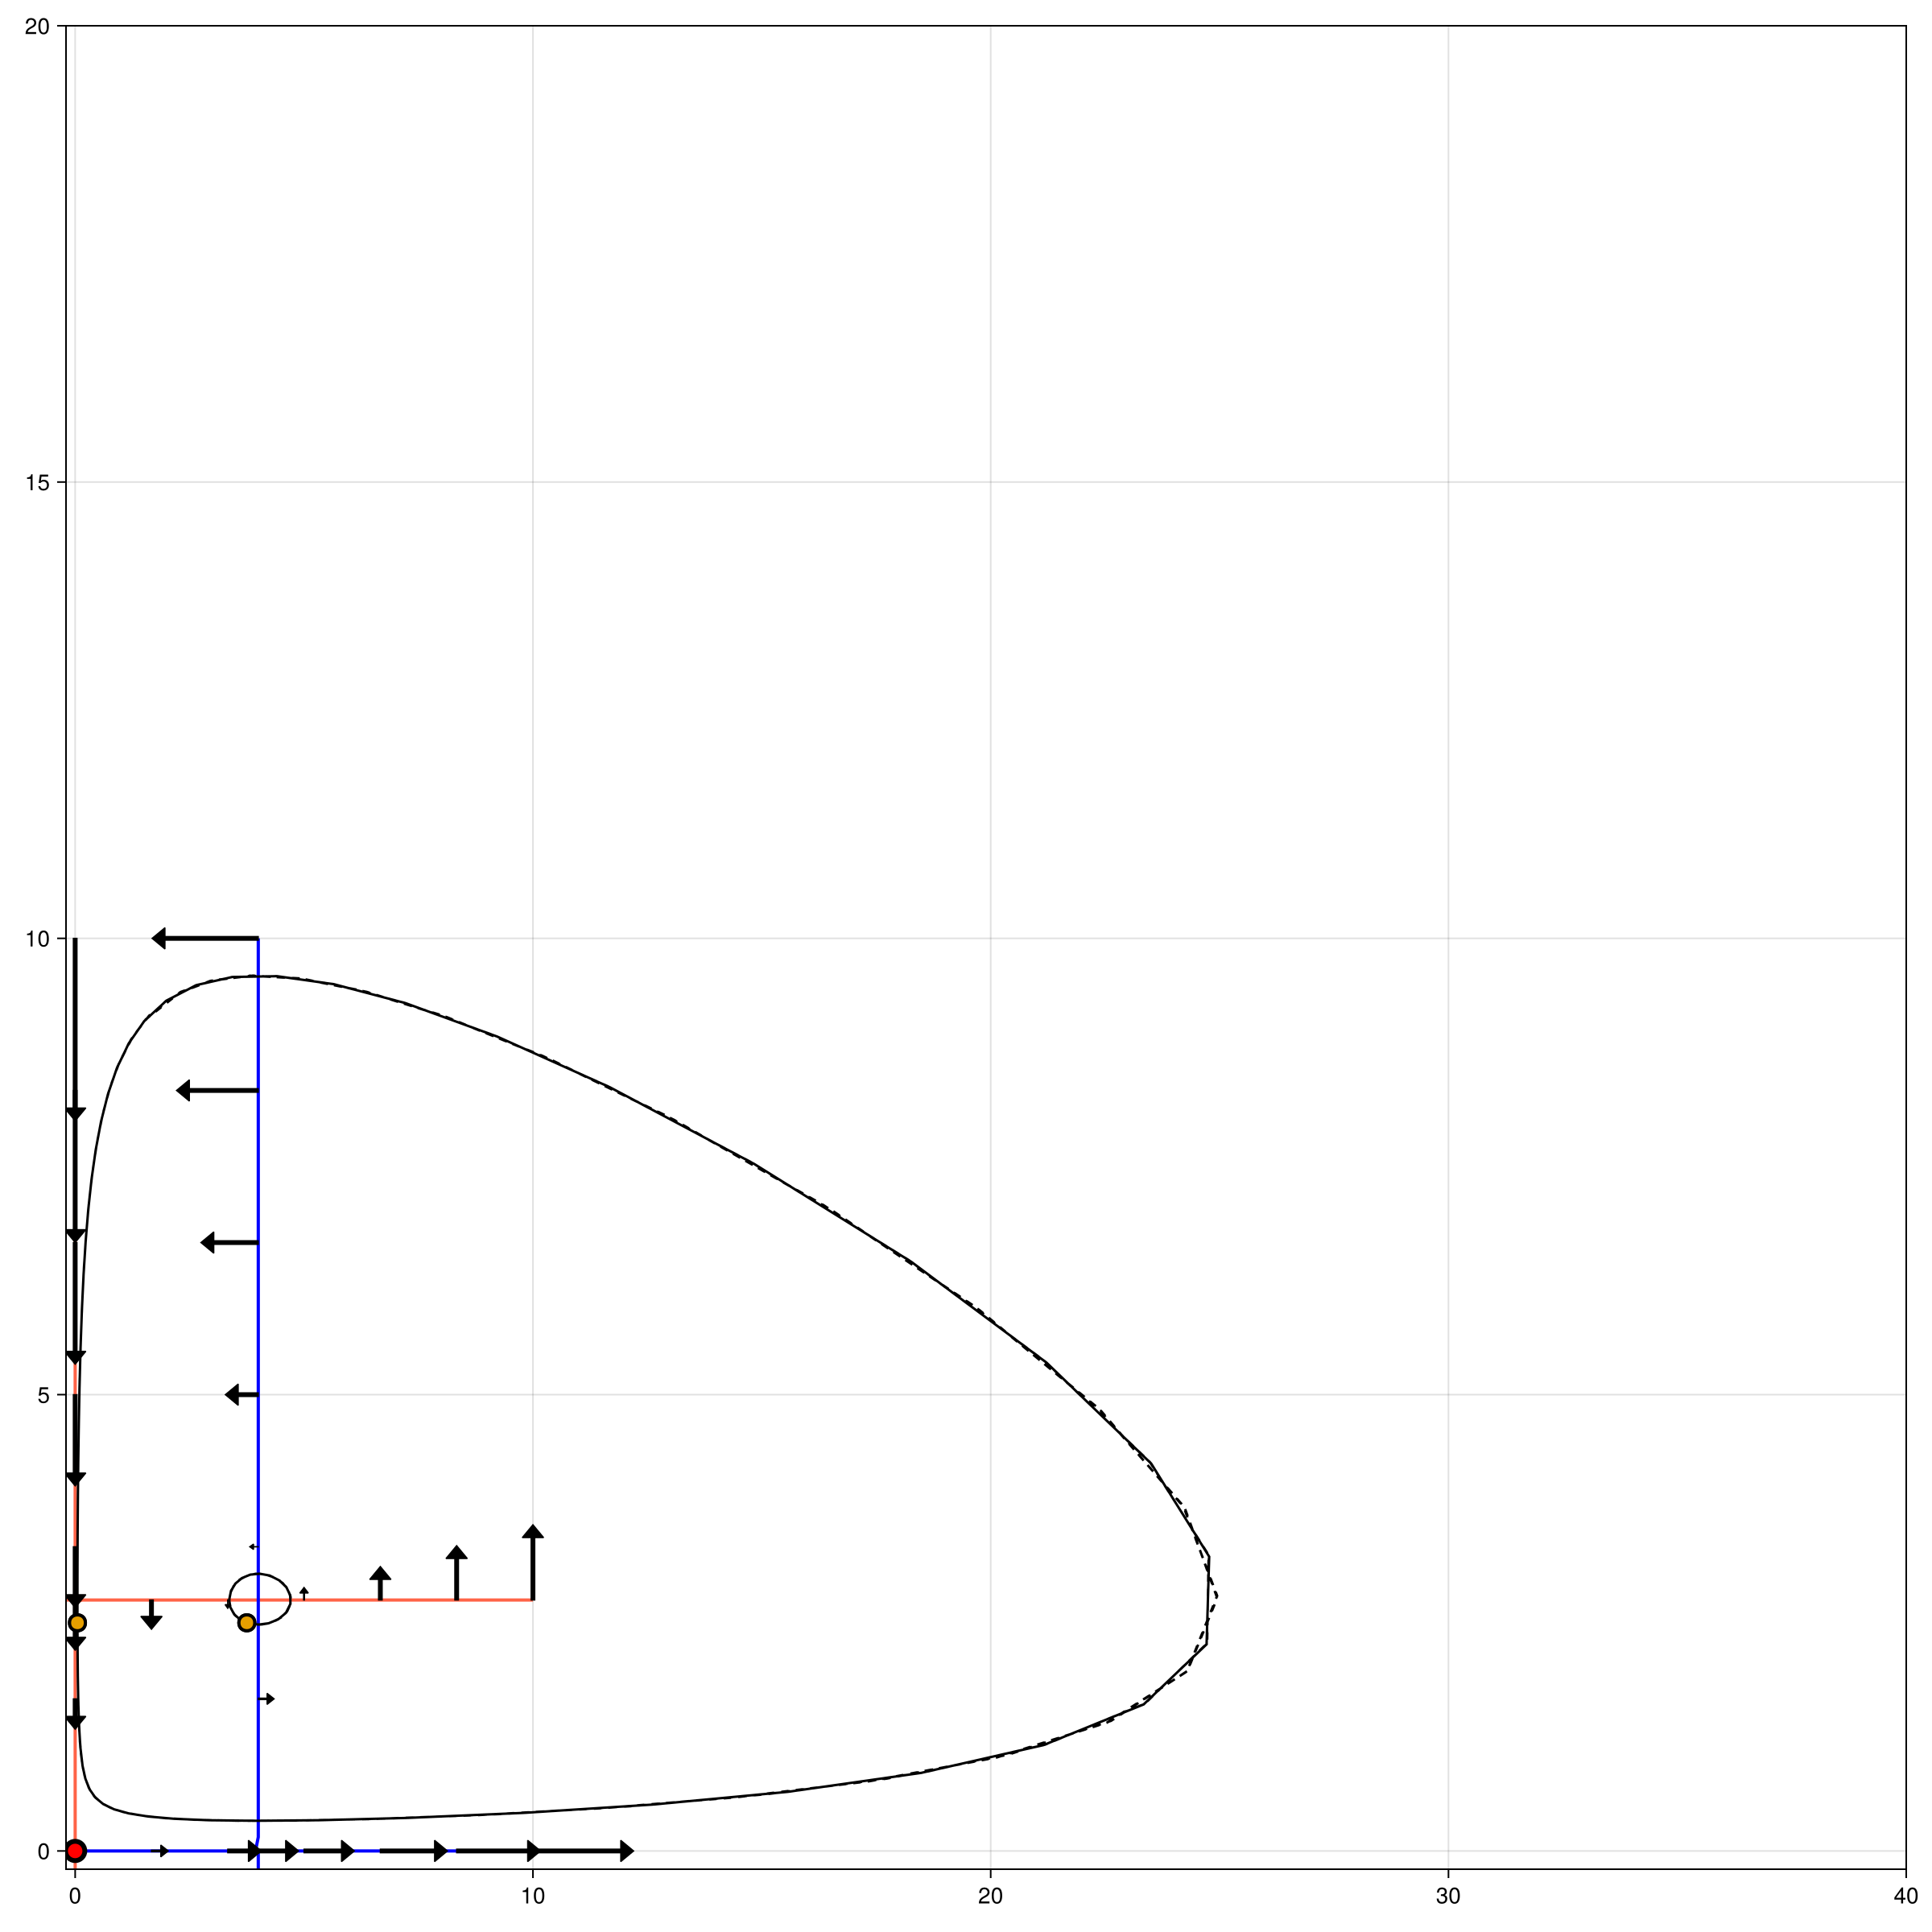

In [68]:

fig = Figure(size=(1200,1200))
ga = fig[1,1] = GridLayout()
ax1 = Axis(ga[1,1]) 


param_dict = Dict(α => params[1] , β => params[2], γ => params[3], δ => params[4])

l_eqs = [[Float64(eq[1].subs(param_dict)), Float64(eq[2].subs(param_dict))] for eq in equilibria] 


draw_arrows_on_nullcline!(ax1, prey_predator!, 1, params, :tomato, 2, 0.5)
draw_arrows_on_nullcline!(ax1, prey_predator!, 2, params, :blue, 2, 0.2)


scatter!(ax1, [l_eqs[1][1]],[l_eqs[1][2]], markersize=17, strokewidth=3, color=:red)
scatter!(ax3, [l_eqs[2][1]],[l_eqs[2][2]], markersize=17, strokewidth=3, color=:red)


init1 = [0.05, 2.5]
init2 = [3.75, 2.5]


l_inits = [init1, init2]
tspan = (0.0,200)

for init in l_inits
    prob = ODEProblem(prey_predator!, init, tspan, params,reltol=1e-8, abstol=1e-8)
    sol = solve(prob)
    lines!(ax1, sol[1,:], sol[2,:], color=:black, linestyle=:dash, linewidth=1.5)
end

scatter!(ax1, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
scatter!(ax1, [init1[1],init2[1]],[init1[2], init2[2]], markersize=14, strokewidth=2)
xlims!(ax1, -0.2,40)
ylims!(ax1, -0.2,20)


fig

## A model of neural excitability and oscillation
$$
\begin{split}
\frac{dv}{dt} = - \overline{g_{Ca}}m_{\infty}(v)(v-1) - \overline{g_{K}}w(v-v_{K}) - \overline{g_L}(v - v_L) + i\\
\frac{dw}{dt} = \phi\frac{(w_{\infty}(v) - w)}{\tau_{w}(v)}
\end{split}
$$

where

![myfig](auxilary_functions.png)


In [75]:
v1, v2, v3, v4 = -0.01, 0.15, 0.0, 0.3
minf(v) = 0.5*(1.0+tanh((v-v1)/v2))
winf(v) = 0.5*(1.0+tanh((v-v3)/v4))
tauw(v) = 1.0/cosh((v-v3)/(2*v4))

tauw (generic function with 1 method)

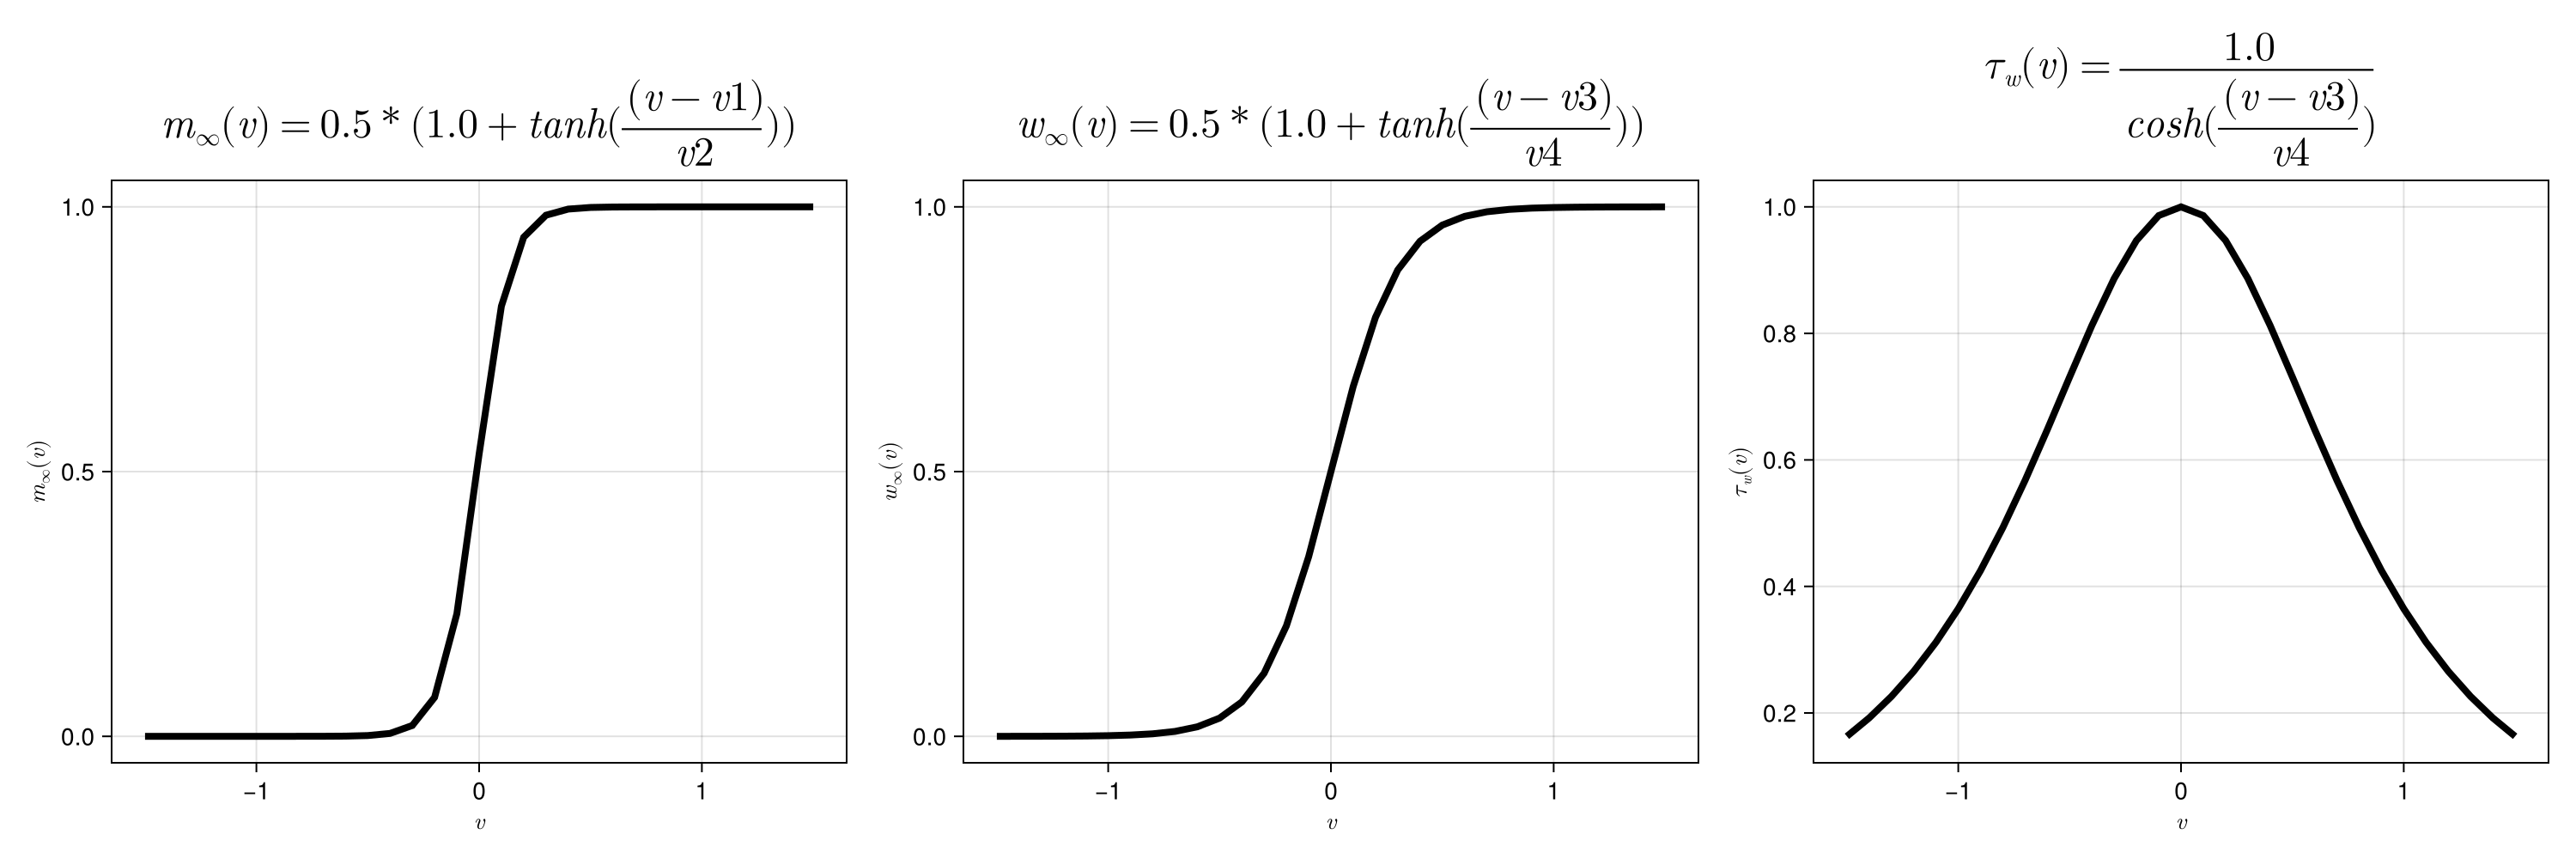

In [91]:
v = -1.5:0.1:1.5
fig = Figure(size=(1500,500))
ax1 = Axis(fig[1,1])
ax2 = Axis(fig[1,2])
ax3 = Axis(fig[1,3])
lines!(ax1, v, minf.(v), color=:black, linewidth=4)
ax1.title=L"$m_{\infty}(v) = 0.5*(1.0+tanh(\frac{(v-v1)}{v2}))$"
ax1.titlesize=24
ax1.xlabel=L"$v$"
ax1.ylabel=L"$m_{\infty}(v)$"
lines!(ax2, v, winf.(v), color=:black, linewidth=4)
ax2.title=L"$w_{\infty}(v) = 0.5*(1.0+tanh(\frac{(v-v3)}{v4}))$"
ax2.titlesize=24
ax2.xlabel=L"$v$"
ax2.ylabel=L"$w_{\infty}(v)$"
lines!(ax3, v, tauw.(v), color=:black, linewidth=4)
ax3.title=L"$\tau_{w}(v) = \frac{1.0}{cosh(\frac{(v-v3)}{v4})}$"
ax3.titlesize=24
ax3.xlabel=L"$v$"
ax3.ylabel=L"$\tau_{w}(v)$"
save("auxilary_functions.png", fig)
fig